In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer
import torch as pt
import re
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from tqdm import tqdm
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec

/Users/jordan/Desktop/Live_Projects/FYP_Documents/.venv3-13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def scale_data(dataframe, oversample=False):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  x = scaler.fit_transform(x)

  if oversample:
    ros = RandomOverSampler()
    x, y = ros.fit_resample(x, y)

  data = np.hstack((x, np.reshape(y, (-1, 1))))

  return data, x, y

In [ ]:
df = pd.read_csv("preprocessed_datasets/bert_features_with_labels.csv")

In [ ]:
train = df.sample(frac=0.8, random_state=42)
test = df.drop(train.index)

In [ ]:
print(f"Total rows in dataset: {len(df)}")
print(f"Total rows in train set: {len(train)}")
print(f"Total rows in test set: {len(test)}")

print("\nClass distribution in full dataset:")
print(df['label'].value_counts())

print("\nClass distribution in train set:")
print(train['label'].value_counts())

print("\nClass distribution in test set:")
print(test['label'].value_counts())

Total rows in dataset: 14336
Total rows in train set: 11469
Total rows in test set: 2867

Class distribution in full dataset:
label
1    7511
0    6825
Name: count, dtype: int64

Class distribution in train set:
label
1    5984
0    5485
Name: count, dtype: int64

Class distribution in test set:
label
1    1527
0    1340
Name: count, dtype: int64


In [ ]:
train, xtrain, ytrain = scale_data(train)
test, xtest, ytest = scale_data(test)

In [ ]:
print(f"xtrain shape: {xtrain.shape}")
print(f"ytrain shape: {ytrain.shape}")
print(f"xtest shape: {xtest.shape}")
print(f"ytest shape: {ytest.shape}")

xtrain shape: (11469, 768)
ytrain shape: (11469,)
xtest shape: (2867, 768)
ytest shape: (2867,)


In [ ]:
print(sum(ytrain == 1))
print(sum(ytrain == 0))

print(sum(ytest == 1))
print(sum(ytest == 0))

5984
5485
1527
1340


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(xtrain, ytrain)

ypred = knn_model.predict(xtest)
print(ypred)
print(ytest)
print(classification_report(ytest, ypred))

[1 1 1 ... 1 0 1]
[1 1 1 ... 1 0 1]
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1340
           1       0.90      0.90      0.90      1527

    accuracy                           0.90      2867
   macro avg       0.89      0.89      0.89      2867
weighted avg       0.90      0.90      0.90      2867



In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model = nb_model.fit(xtrain, ytrain)

ypred = nb_model.predict(xtest)

print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.79      0.78      0.78      1340
           1       0.81      0.81      0.81      1527

    accuracy                           0.80      2867
   macro avg       0.80      0.80      0.80      2867
weighted avg       0.80      0.80      0.80      2867



In [ ]:
from sklearn.linear_model import LogisticRegression

lgr_model = LogisticRegression()
lgr_model = lgr_model.fit(xtrain, ytrain)

ypred = lgr_model.predict(xtest)

print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1340
           1       0.95      0.94      0.94      1527

    accuracy                           0.94      2867
   macro avg       0.94      0.94      0.94      2867
weighted avg       0.94      0.94      0.94      2867



/Users/jordan/Desktop/Live_Projects/FYP_Documents/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.svm import SVC

svc_model = SVC()
svc_model = svc_model.fit(xtrain, ytrain)

ypred = svc_model.predict(xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1340
           1       0.96      0.94      0.95      1527

    accuracy                           0.95      2867
   macro avg       0.95      0.95      0.95      2867
weighted avg       0.95      0.95      0.95      2867



In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model = xgb_model.fit(xtrain, ytrain)

ypred = xgb_model.predict(xtest)
print(classification_report(ytest, ypred))

/Users/jordan/Desktop/Live_Projects/FYP_Documents/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [14:14:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1340
           1       0.93      0.92      0.92      1527

    accuracy                           0.92      2867
   macro avg       0.92      0.92      0.92      2867
weighted avg       0.92      0.92      0.92      2867



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(xtrain, ytrain)

ypred = rf_model.predict(xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1340
           1       0.88      0.87      0.88      1527

    accuracy                           0.87      2867
   macro avg       0.87      0.87      0.87      2867
weighted avg       0.87      0.87      0.87      2867



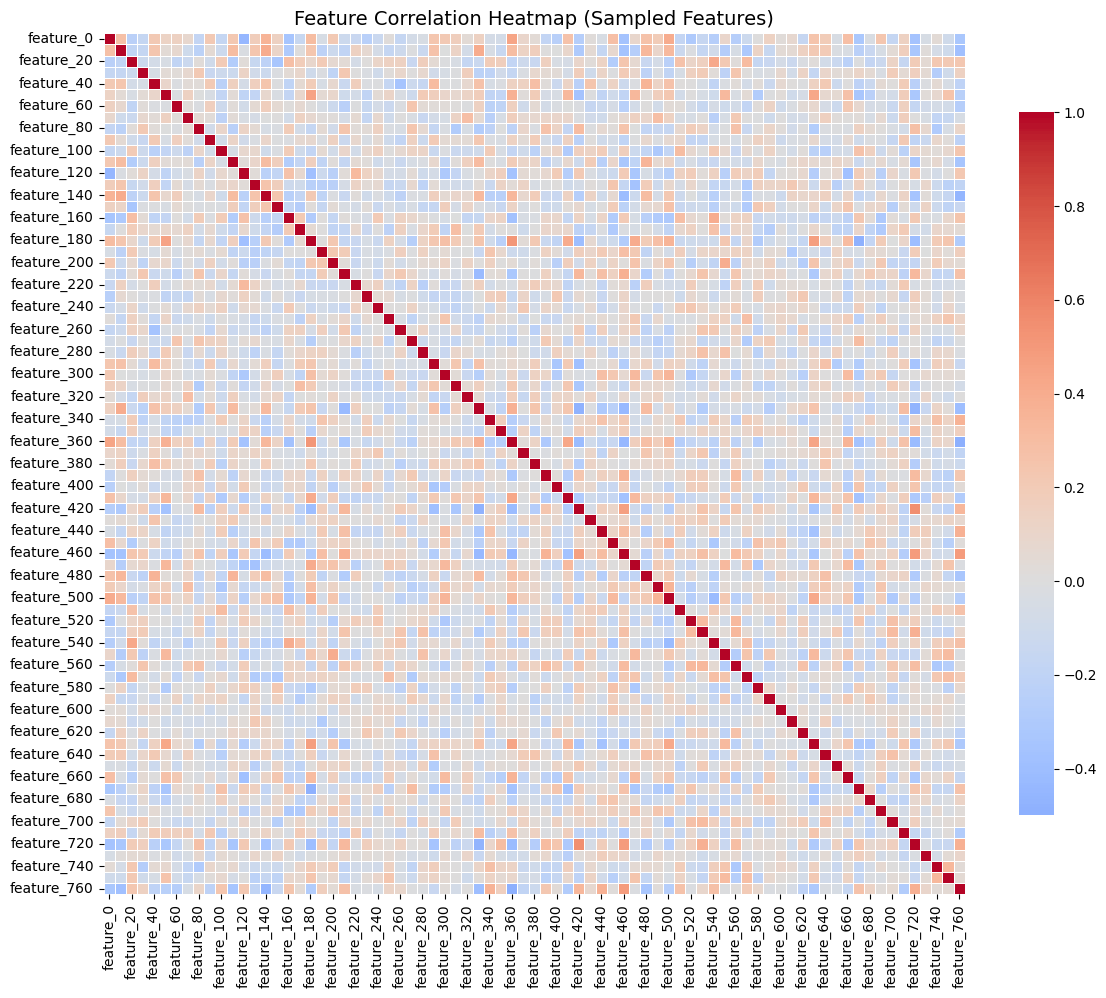

In [ ]:
feature_cols = [col for col in df.columns if col.startswith('feature_')]
sample_features = feature_cols[::10]  # Every 10th feature

corr_matrix = df[sample_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap (Sampled Features)', fontsize=14)
plt.tight_layout()
plt.show()

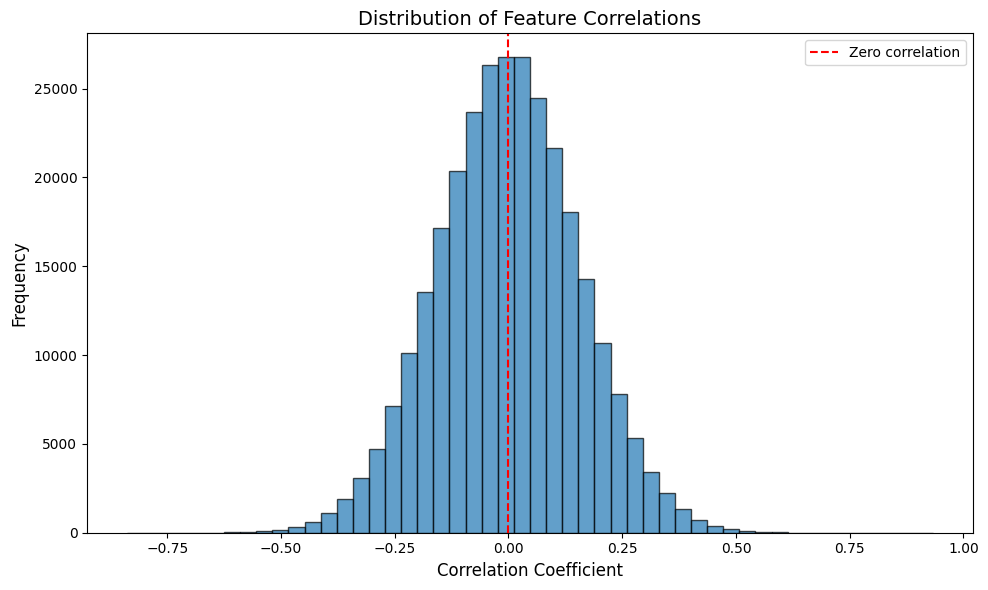

Mean correlation: -0.0012
Median correlation: -0.0009
Max correlation: 0.9323
Min correlation: -0.8374


In [ ]:
all_corr = df[feature_cols].corr()
corr_values = all_corr.values[np.triu_indices_from(all_corr.values, k=1)]

plt.figure(figsize=(10, 6))
plt.hist(corr_values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Feature Correlations', fontsize=14)
plt.axvline(x=0, color='red', linestyle='--', label='Zero correlation')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean correlation: {corr_values.mean():.4f}")
print(f"Median correlation: {np.median(corr_values):.4f}")
print(f"Max correlation: {corr_values.max():.4f}")
print(f"Min correlation: {corr_values.min():.4f}")

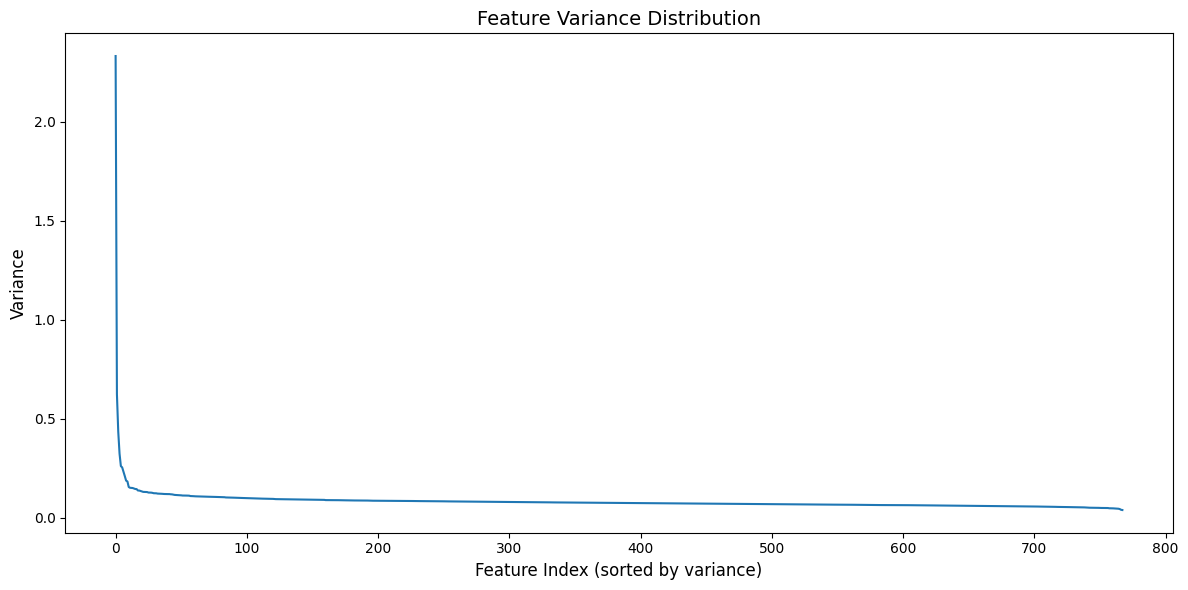


Top 10 most variable features:
feature_752    2.330459
feature_273    0.623656
feature_667    0.435791
feature_308    0.324116
feature_109    0.261628
feature_142    0.254951
feature_588    0.233937
feature_46     0.211081
feature_562    0.188172
feature_94     0.184168
dtype: float64


In [ ]:
variances = df[feature_cols].var().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.plot(range(len(variances)), variances.values)
plt.xlabel('Feature Index (sorted by variance)', fontsize=12)
plt.ylabel('Variance', fontsize=12)
plt.title('Feature Variance Distribution', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nTop 10 most variable features:")
print(variances.head(10))

In [ ]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset

# 1. Setup Device (MPS for Mac, CUDA for Nvidia, CPU otherwise)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

# 2. Load and Prepare Data
# Load one of your processed datasets
df = pd.read_csv("processed_datasets/WELFake_Dataset_processed.csv").dropna()

# Optional: Sample data for faster testing/debugging
# df = df.sample(2000, random_state=42) 

# Split into train and validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['combined_text'].tolist(), 
    df['label'].tolist(), 
    test_size=0.2, 
    random_state=42
)

# 3. Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize the text
# truncation=True: Cut text longer than max_length
# padding=True: Pad shorter text to max_length
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

# 4. Create PyTorch Dataset
class FakeNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = FakeNewsDataset(train_encodings, train_labels)
val_dataset = FakeNewsDataset(val_encodings, val_labels)

# 5. Load Pre-trained BERT Model
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model.to(device)

# 6. Define Training Arguments
training_args = TrainingArguments(
    output_dir='./results',          # Output directory
    num_train_epochs=3,              # Total number of training epochs
    per_device_train_batch_size=16,  # Batch size per device during training (8 or 16 for M1)
    per_device_eval_batch_size=64,   # Batch size for evaluation
    warmup_steps=500,                # Number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # Strength of weight decay
    logging_dir='./logs',            # Directory for storing logs
    logging_steps=10,
    eval_strategy="epoch",           # Evaluate every epoch
    save_strategy="epoch",           # Save checkpoint every epoch
    load_best_model_at_end=True,     # Load the best model when finished
)

# 7. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

# 8. Train the Model
trainer.train()

# 9. Save the Final Model
model.save_pretrained("./fake_news_bert_model")
tokenizer.save_pretrained("./fake_news_bert_model")
print("Training complete and model saved.")

Using MPS (Apple Silicon GPU)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/jordan/Desktop/Live_Projects/FYP_Documents/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [ ]:
# 1. Load GloVe Embeddings
def load_glove_embeddings(glove_file_path):
    print(f"Loading GloVe embeddings from {glove_file_path}...")
    embeddings_index = {}
    try:
        with open(glove_file_path, encoding='utf-8') as f:
            for line in f:
                values = line.split()
                word = values[0]
                # Handle cases where a line might be malformed
                try:
                    coefs = np.asarray(values[1:], dtype='float32')
                    embeddings_index[word] = coefs
                except ValueError:
                    continue
        print(f"Found {len(embeddings_index)} word vectors.")
        return embeddings_index
    except FileNotFoundError:
        print(f"Error: File not found at {glove_file_path}")
        print("Please ensure 'glove.6B.100d.txt' is in the correct directory.")
        return {}

# 2. Generate Averaged Embeddings (Pure Python/Numpy)
def get_averaged_glove_features(texts, embeddings_index, embedding_dim=100):
    """
    Converts a list of text strings into a list of averaged GloVe vectors.
    """
    features = []
    for text in tqdm(texts, desc="Vectorizing texts"):
        if not isinstance(text, str):
            text = ""
            
        # Simple tokenization: lowercase and split by whitespace
        words = text.lower().split()
        
        # Filter for words present in GloVe
        valid_vectors = [embeddings_index[w] for w in words if w in embeddings_index]
        
        if valid_vectors:
            # Average the vectors
            avg_vector = np.mean(valid_vectors, axis=0)
        else:
            # If no words found (or empty text), return zero vector
            avg_vector = np.zeros(embedding_dim)
            
        features.append(avg_vector)
        
    return np.array(features)

In [6]:
glove_path = 'dolma_300_2024_1.2M.100_combined.txt' 

embeddings_index = load_glove_embeddings(glove_path)

if embeddings_index:
    # Load Data
    print("Loading dataset...")
    df = pd.read_csv("processed_datasets/WELFake_Dataset_processed.csv")
    
    # Ensure text column is string
    df['combined_text'] = df['combined_text'].astype(str)
    
    texts = df['combined_text'].tolist()
    labels = df['label'].values

    # FIX: Determine embedding dimension from the loaded data automatically
    # This prevents mismatch between loaded vectors and the zero-vector fallback
    if len(embeddings_index) > 0:
        sample_key = next(iter(embeddings_index))
        embedding_dim = len(embeddings_index[sample_key])
        print(f"Detected embedding dimension: {embedding_dim}")
    else:
        embedding_dim = 100 # Fallback default

    # Generate Features
    X_glove = get_averaged_glove_features(texts, embeddings_index, embedding_dim)

    # Create DataFrame
    glove_feature_cols = [f'glove_{i}' for i in range(embedding_dim)]
    glove_df = pd.DataFrame(X_glove, columns=glove_feature_cols)
    glove_df['label'] = labels

    # Save
    output_path = 'preprocessed_datasets/glove_features_averaged.csv'
    glove_df.to_csv(output_path, index=False)
    print(f"Averaged GloVe features saved to {output_path}")

Loading GloVe embeddings from dolma_300_2024_1.2M.100_combined.txt...
Found 1200001 word vectors.
Loading dataset...
Detected embedding dimension: 300


Vectorizing texts: 100%|██████████| 72124/72124 [00:47<00:00, 1530.31it/s]


Averaged GloVe features saved to preprocessed_datasets/glove_features_averaged.csv


In [2]:
df = pd.read_csv("preprocessed_datasets/glove_features_averaged.csv")

df.head()

,glove_0,glove_1,glove_2,glove_3,glove_4,glove_5,glove_6,glove_7,glove_8,glove_9,...,glove_291,glove_292,glove_293,glove_294,glove_295,glove_296,glove_297,glove_298,glove_299,label
0,-0.087969,-0.065743,-0.197766,-0.025432,0.044824,-0.132333,-0.161037,-0.006665,0.918580,-0.023367,...,0.045207,0.174155,-0.022262,-0.112820,0.003164,0.193079,0.372457,-0.013245,0.011839,1
1,-0.097187,-0.049914,-0.311329,-0.189515,0.029972,-0.138930,-0.164260,0.009709,1.180396,0.048713,...,-0.040974,0.188815,0.048454,-0.164614,-0.097104,0.213931,0.277798,0.109681,0.015956,1
2,-0.159360,-0.058271,-0.151604,-0.023289,0.012202,-0.233306,-0.113569,-0.003830,0.783874,-0.082330,...,0.067064,0.083402,-0.020227,-0.103164,0.012808,0.149834,0.359297,0.108930,-0.006429,1
3,-0.126454,-0.056505,-0.172090,-0.031410,-0.004020,-0.158922,-0.143521,0.000892,0.906343,-0.011381,...,0.041894,0.178555,0.003800,-0.102395,0.000989,0.198056,0.344069,-0.030789,0.027161,0
4,-0.072542,-0.118940,-0.174961,0.031754,0.065772,-0.177495,-0.108461,0.074498,0.619597,-0.005935,...,-0.010755,0.178652,0.021008,-0.082601,0.052799,0.152559,0.316286,-0.005364,0.000829,1


In [3]:
def scale_data(dataframe, oversample=False):
  x = dataframe[dataframe.columns[:-1]].values
  y = dataframe[dataframe.columns[-1]].values

  scaler = StandardScaler()
  x = scaler.fit_transform(x)

  if oversample:
    ros = RandomOverSampler()
    x, y = ros.fit_resample(x, y)

  data = np.hstack((x, np.reshape(y, (-1, 1))))

  return data, x, y

In [4]:
train = df.sample(frac=0.8, random_state=42)
test = df.drop(train.index)

In [8]:
print(f"Total rows in dataset: {len(df)}")
print(f"Total rows in train set: {len(train)}")
print(f"Total rows in test set: {len(test)}")

print("\nClass distribution in full dataset:")
print(df['label'].value_counts())

print("\nClass distribution in train set:")
print(train['label'].value_counts())

print("\nClass distribution in test set:")
print(test['label'].value_counts())

Total rows in dataset: 72124
Total rows in train set: 57699
Total rows in test set: 14425

Class distribution in full dataset:
label
1    37096
0    35028
Name: count, dtype: int64

Class distribution in train set:
label
1    29653
0    28046
Name: count, dtype: int64

Class distribution in test set:
label
1    7443
0    6982
Name: count, dtype: int64


In [5]:
train, xtrain, ytrain = scale_data(train)
test, xtest, ytest = scale_data(test)

In [10]:
print(sum(ytrain == 1))
print(sum(ytrain == 0))

print(sum(ytest == 1))
print(sum(ytest == 0))

29653
28046
7443
6982


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(xtrain, ytrain)

ypred = knn_model.predict(xtest)
print(ypred)
print(ytest)
print(classification_report(ytest, ypred))

[0 1 1 ... 0 1 0]
[1 1 1 ... 0 1 0]
              precision    recall  f1-score   support

           0       0.81      0.91      0.86      6982
           1       0.90      0.80      0.85      7443

    accuracy                           0.85     14425
   macro avg       0.86      0.85      0.85     14425
weighted avg       0.86      0.85      0.85     14425



In [12]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model = nb_model.fit(xtrain, ytrain)

ypred = nb_model.predict(xtest)

print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.62      0.87      0.72      6982
           1       0.80      0.50      0.62      7443

    accuracy                           0.68     14425
   macro avg       0.71      0.68      0.67     14425
weighted avg       0.71      0.68      0.67     14425



In [13]:
from sklearn.linear_model import LogisticRegression

lgr_model = LogisticRegression()
lgr_model = lgr_model.fit(xtrain, ytrain)

ypred = lgr_model.predict(xtest)

print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      6982
           1       0.90      0.90      0.90      7443

    accuracy                           0.89     14425
   macro avg       0.89      0.89      0.89     14425
weighted avg       0.89      0.89      0.89     14425



/Users/jordan/Desktop/Live_Projects/FYP_Documents/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.svm import SVC

svc_model = SVC()
svc_model = svc_model.fit(xtrain, ytrain)

ypred = svc_model.predict(xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      6982
           1       0.94      0.94      0.94      7443

    accuracy                           0.94     14425
   macro avg       0.94      0.94      0.94     14425
weighted avg       0.94      0.94      0.94     14425



In [15]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model = xgb_model.fit(xtrain, ytrain)

ypred = xgb_model.predict(xtest)
print(classification_report(ytest, ypred))

/Users/jordan/Desktop/Live_Projects/FYP_Documents/.venv/lib/python3.14/site-packages/xgboost/training.py:199: UserWarning: [08:52:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.92      0.91      0.92      6982
           1       0.92      0.93      0.92      7443

    accuracy                           0.92     14425
   macro avg       0.92      0.92      0.92     14425
weighted avg       0.92      0.92      0.92     14425



In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(xtrain, ytrain)

ypred = rf_model.predict(xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89      6982
           1       0.89      0.92      0.90      7443

    accuracy                           0.90     14425
   macro avg       0.90      0.90      0.90     14425
weighted avg       0.90      0.90      0.90     14425



In [7]:
def train_model(xtrain, ytrain, nodes, dropout_rate, learning_rate, batch_size, epochs):
    
    # Split data for validation
    X_train, X_val, y_train, y_val = train_test_split(
        xtrain, ytrain, test_size=0.2, random_state=42
    )
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
    X_val_tensor = torch.FloatTensor(X_val)
    y_val_tensor = torch.FloatTensor(y_val).reshape(-1, 1)
    
    # Create DataLoaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    # Define the model
    class NeuralNetwork(nn.Module):
        def __init__(self, input_size, nodes, dropout_rate):
            super(NeuralNetwork, self).__init__()
            self.fc1 = nn.Linear(input_size, nodes)
            self.dropout1 = nn.Dropout(dropout_rate)
            self.fc2 = nn.Linear(nodes, nodes)
            self.dropout2 = nn.Dropout(dropout_rate)
            self.fc3 = nn.Linear(nodes, 1)
            self.relu = nn.ReLU()
            self.sigmoid = nn.Sigmoid()
        
        def forward(self, x):
            x = self.relu(self.fc1(x))
            x = self.dropout1(x)
            x = self.relu(self.fc2(x))
            x = self.dropout2(x)
            x = self.sigmoid(self.fc3(x))
            return x
    
    # Initialize model
    input_size = xtrain.shape[1]
    nn_model = NeuralNetwork(input_size, nodes, dropout_rate)
    
    # Set device
    device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
    nn_model.to(device)
    
    # Loss and optimizer
    criterion = nn.BCELoss()
    optimizer = optim.Adam(nn_model.parameters(), lr=learning_rate)
    
    # Training history
    history = {
        'loss': [],
        'accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    # Training loop
    for epoch in range(epochs):
        # Training phase
        nn_model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = nn_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            predicted = (outputs >= 0.5).float()
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        # Validation phase
        nn_model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = nn_model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                predicted = (outputs >= 0.5).float()
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        # Record history
        history['loss'].append(train_loss / len(train_loader))
        history['accuracy'].append(train_correct / train_total)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_accuracy'].append(val_correct / val_total)
    
    return nn_model, history

def binary_inference(nn_model, input_list, threshold=0.8):
    """
    Make predictions with custom threshold
    """
    device = next(nn_model.parameters()).device
    nn_model.eval()
    
    with torch.no_grad():
        if not isinstance(input_list, torch.Tensor):
            input_tensor = torch.FloatTensor(input_list).to(device)
        else:
            input_tensor = input_list.to(device)
        
        probability = nn_model(input_tensor)
        return (probability >= threshold).float()

In [8]:
def plot_loss(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history['loss'], label='loss')
    ax1.plot(history['val_loss'], label='val_loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary Crossentropy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['accuracy'], label='accuracy')
    ax2.plot(history['val_accuracy'], label='val_accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.show()

def plot_accuracy(history):
    plt.plot(history['accuracy'], label='accuracy')
    plt.plot(history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

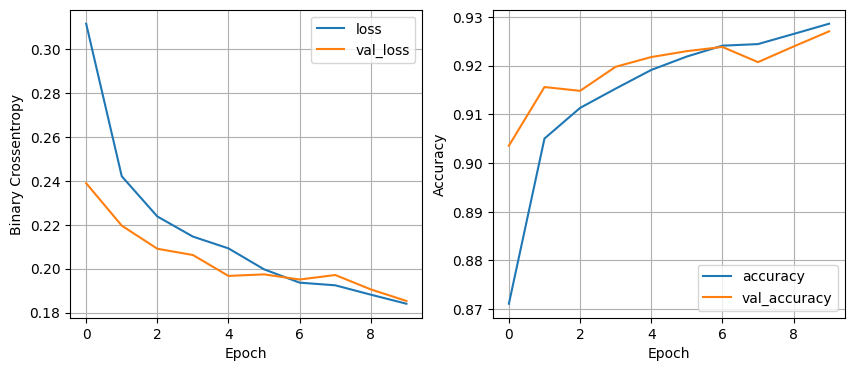

In [11]:
nodes = 32
dropout_rate = 0.3
learning_rate = 0.001
batch_size = 32
epochs = 10


model, history = train_model(xtrain, ytrain, nodes, dropout_rate, learning_rate, batch_size, epochs)
plot_loss(history)
# plot_accuracy(history)

In [ ]:
epochs = 10

for nodes in [16, 24, 32]:
  for dropout_rate in [0, 0.2]:
    for learning_rate in [0.1, 0.005, 0.001]:
      for batch_size in [32, 64, 128]:
        print(f"Nodes: {nodes}, Dropout rate: {dropout_rate}, Learning Rate {learning_rate}, Batch Size: {batch_size}")
        model, history = train_model(xtrain, ytrain, nodes, dropout_rate, learning_rate, batch_size, epochs)
        plot_loss(history)
        # plot_accuracy(history)

In [19]:
# 1. Load and prepare data
def load_texts_for_word2vec(csv_path):
    """Load texts from CSV and tokenize for Word2Vec training"""
    print(f"Loading data from {csv_path}...")
    df = pd.read_csv(csv_path)
    df['combined_text'] = df['combined_text'].astype(str)
    
    # Tokenize texts (simple whitespace tokenization)
    tokenized_texts = [text.lower().split() for text in df['combined_text']]
    labels = df['label'].values
    
    return tokenized_texts, labels, df

# 2. Train Word2Vec model
def train_word2vec(tokenized_texts, vector_size=100, window=5, min_count=2, workers=4, epochs=10):
    """
    Train Word2Vec model
    
    Parameters:
    - vector_size: dimensionality of word vectors (100, 200, 300)
    - window: context window size
    - min_count: ignores words with frequency lower than this
    - workers: number of worker threads
    - epochs: number of training epochs
    """
    print("Training Word2Vec model...")
    model = Word2Vec(
        sentences=tokenized_texts,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers,
        epochs=epochs,
        sg=1  # 1 for skip-gram, 0 for CBOW
    )
    print(f"Word2Vec model trained with vocabulary size: {len(model.wv)}")
    return model

# 3. Generate averaged Word2Vec features IN CHUNKS
def get_word2vec_features_chunked(tokenized_texts, w2v_model, labels, output_path, vector_size=100, chunk_size=1000):
    """Convert tokenized texts to averaged Word2Vec vectors and save in chunks"""
    
    # Create column names
    w2v_feature_cols = [f'w2v_{i}' for i in range(vector_size)]
    
    # Write header first
    header_df = pd.DataFrame(columns=w2v_feature_cols + ['label'])
    header_df.to_csv(output_path, index=False)
    
    # Process in chunks
    total_texts = len(tokenized_texts)
    num_chunks = (total_texts + chunk_size - 1) // chunk_size
    
    for chunk_idx in tqdm(range(num_chunks), desc="Processing chunks"):
        start_idx = chunk_idx * chunk_size
        end_idx = min((chunk_idx + 1) * chunk_size, total_texts)
        
        # Process current chunk
        chunk_features = []
        for tokens in tokenized_texts[start_idx:end_idx]:
            # Get vectors for words in vocabulary
            valid_vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
            
            if valid_vectors:
                # Average the vectors
                avg_vector = np.mean(valid_vectors, axis=0)
            else:
                # Zero vector if no words found
                avg_vector = np.zeros(vector_size)
            
            chunk_features.append(avg_vector)
        
        # Create DataFrame for this chunk
        chunk_array = np.array(chunk_features)
        chunk_df = pd.DataFrame(chunk_array, columns=w2v_feature_cols)
        chunk_df['label'] = labels[start_idx:end_idx]
        
        # Append to CSV (without header)
        chunk_df.to_csv(output_path, mode='a', header=False, index=False)
        
        # Clear memory
        del chunk_features, chunk_array, chunk_df
    
    print(f"Word2Vec features saved to {output_path}")

# 4. Complete pipeline with chunked saving
def create_word2vec_features(csv_path, output_path, vector_size=100, window=5, chunk_size=1000):
    """Complete pipeline to create Word2Vec features with memory-efficient saving"""
    
    # Load and tokenize
    tokenized_texts, labels, original_df = load_texts_for_word2vec(csv_path)
    
    # Train Word2Vec
    w2v_model = train_word2vec(
        tokenized_texts, 
        vector_size=vector_size, 
        window=window
    )
    
    # Generate and save features in chunks
    get_word2vec_features_chunked(
        tokenized_texts, 
        w2v_model, 
        labels, 
        output_path, 
        vector_size=vector_size,
        chunk_size=chunk_size
    )
    
    # Save the model
    model_path = output_path.replace('.csv', '.model')
    w2v_model.save(model_path)
    print(f"Word2Vec model saved to {model_path}")
    
    # Return model and first few rows for verification
    verification_df = pd.read_csv(output_path, nrows=5)
    
    return verification_df, w2v_model

In [20]:
w2v_df, w2v_model = create_word2vec_features(
    csv_path='final_datasets/Combined_Train.csv',
    output_path='preprocessed_datasets/word2vec_features.csv',
    vector_size=100,  # 100, 200, or 300
    window=5,
    chunk_size=100
)

print("\nWord2Vec features generated!")
print(f"Shape: {w2v_df.shape}")
w2v_df.head()

Loading data from final_datasets/Combined_Train.csv...
Training Word2Vec model...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Word2Vec model trained with vocabulary size: 425189


Processing chunks: 100%|██████████| 1801/1801 [02:51<00:00, 10.47it/s]


Word2Vec features saved to preprocessed_datasets/word2vec_features.csv
Word2Vec model saved to preprocessed_datasets/word2vec_features.model

Word2Vec features generated!
Shape: (5, 101)


,w2v_0,w2v_1,w2v_2,w2v_3,w2v_4,w2v_5,w2v_6,w2v_7,w2v_8,w2v_9,...,w2v_91,w2v_92,w2v_93,w2v_94,w2v_95,w2v_96,w2v_97,w2v_98,w2v_99,label
0,-0.088032,0.216574,0.071848,-0.047545,0.058198,-0.256617,0.260833,0.349325,-0.071233,0.019895,...,0.007162,0.108326,-0.048984,0.199117,0.193159,0.010972,-0.129852,-0.008635,-0.025235,1
1,-0.105712,0.164476,0.113690,-0.072790,0.047659,-0.264727,0.198774,0.418022,-0.094503,-0.068364,...,-0.031178,0.161627,0.003181,0.201607,0.181485,-0.037429,-0.178130,-0.130464,-0.065710,0
2,-0.052271,0.156961,0.104463,-0.031137,-0.004413,-0.282800,0.173517,0.376382,-0.055175,-0.168959,...,0.014802,0.117292,-0.042914,0.229592,0.126582,-0.080868,-0.130012,-0.070988,-0.104734,1
3,-0.001157,0.231302,0.040211,-0.092716,0.109829,-0.264168,0.174594,0.458767,-0.087711,-0.222695,...,0.062020,0.120198,-0.043880,0.228383,0.158327,-0.116205,-0.136470,-0.038554,-0.114638,0
4,-0.081945,0.190545,0.036891,-0.018873,-0.040791,-0.260958,0.199944,0.391738,-0.177649,-0.122187,...,0.070465,0.195436,-0.049793,0.194982,0.188618,-0.036434,-0.102704,-0.022445,-0.066967,1


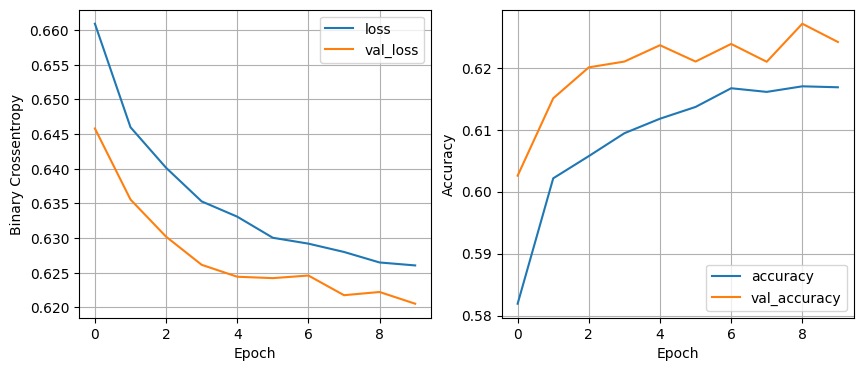

In [9]:
df = pd.read_csv("preprocessed_datasets/word2vec_features.csv")

train = df.sample(frac=0.8, random_state=42)
test = df.drop(train.index)

train, xtrain, ytrain = scale_data(train)
test, xtest, ytest = scale_data(test)

model, history = train_model(xtrain, ytrain, nodes=32, dropout_rate=0.3, learning_rate=0.001, batch_size=32, epochs=10)
plot_loss(history)

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(xtrain, ytrain)

ypred = knn_model.predict(xtest)
print(ypred)
print(ytest)
print(classification_report(ytest, ypred))

[1 1 0 ... 1 1 0]
[0 1 0 ... 0 0 1]
              precision    recall  f1-score   support

           0       0.41      0.43      0.42     16582
           1       0.49      0.47      0.48     19425

    accuracy                           0.45     36007
   macro avg       0.45      0.45      0.45     36007
weighted avg       0.45      0.45      0.45     36007



In [11]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model = nb_model.fit(xtrain, ytrain)

ypred = nb_model.predict(xtest)

print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.49      0.85      0.62     16582
           1       0.66      0.25      0.37     19425

    accuracy                           0.53     36007
   macro avg       0.58      0.55      0.49     36007
weighted avg       0.58      0.53      0.48     36007



In [12]:
from sklearn.linear_model import LogisticRegression

lgr_model = LogisticRegression()
lgr_model = lgr_model.fit(xtrain, ytrain)

ypred = lgr_model.predict(xtest)

print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.56      0.50      0.53     16582
           1       0.61      0.66      0.63     19425

    accuracy                           0.59     36007
   macro avg       0.58      0.58      0.58     36007
weighted avg       0.58      0.59      0.58     36007



In [ ]:
# from sklearn.svm import SVC

# svc_model = SVC()
# svc_model = svc_model.fit(xtrain, ytrain)

# ypred = svc_model.predict(xtest)
# print(classification_report(ytest, ypred))

In [13]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model = xgb_model.fit(xtrain, ytrain)

ypred = xgb_model.predict(xtest)
print(classification_report(ytest, ypred))

/Users/jordan/Desktop/Live_Projects/FYP_Documents/.venv3-13/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [14:17:34] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.51      0.48      0.49     16582
           1       0.58      0.60      0.59     19425

    accuracy                           0.55     36007
   macro avg       0.54      0.54      0.54     36007
weighted avg       0.54      0.55      0.55     36007



In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(xtrain, ytrain)

ypred = rf_model.predict(xtest)
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.38      0.36      0.37     16582
           1       0.47      0.49      0.48     19425

    accuracy                           0.43     36007
   macro avg       0.42      0.43      0.42     36007
weighted avg       0.43      0.43      0.43     36007

